## Trabajo Práctico Nro. 3 - CLASIFICANDO INFORMALES EN LA EPH
- Grupo 5 del curso "M73 13 Seminarios Optativos - Taller de Programación"
- Integrantes: Santiago Caballero Yver, Oriana Valentina Gegena y Valeria Eliana Gonzalez.

## Retomando lo hecho en el TP1 y TP2

In [1]:
# Cargamos librerias a utilizar
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Cargamos bases de datos T424 y T425
T424 = pd.read_excel('C:/Users/gegen/OneDrive/Documentos/2. Economía Aplicada/Programación/usu_individual_T424.xlsx')
T425 = pd.read_excel('C:/Users/gegen/OneDrive/Documentos/2. Economía Aplicada/Programación/usu_individual_T425.xlsx')


In [2]:
# Variables de interés a utilizar en el analisis
variables = [
    "CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR", "PONDERA",
    "CH04", "CH06", "CH07", "CH08", "NIVEL_ED",
    "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR",
    "PP04C", "PP04D_COD", "P21", "P47T",
    "PP07H", "PP3E_TOT", "CH12", "CH13", "CH14", "CH03", "PP3F_TOT", "COMPONENTE"
]

T424_v = T424[variables].copy()
T425_v = T425[variables].copy()

# Variables incluidas:
# "PP07H"     Descuento jubilatorio (formalidad asalariada)
# "PP3E_TOT"  Horas trabajadas (salario horario)

#Seguimiento de variables:
#CH04 - Varón/Mujer
#CH06 - edad
#CH07 - Estado civil
#CH08 - Cobertura salud
#PP04C - Cantidad de personas que trabajan en el establecimiento
#PP04D_COD - Codigo de ocupación
#P21 - ingreso de la ocupación principal
#P47T - Ingreso total individual



In [3]:
# Reemplazamos los datos correspondientes a NS/NC a NaN
def reemplazar_nsnc_por_nan(df):
    df_clean = df.copy()

    # Variables categóricas donde 9 es NS/NC
    vars_cat = ['CAT_OCUP', 'EMPLEO', 'SECTOR', 'CH07', 'CH08']
    for col in vars_cat:
        df_clean[col] = df_clean[col].replace(9, np.nan)

    # Códigos específicos de NS/NC del INDEC
    df_clean['PP3E_TOT'] = df_clean['PP3E_TOT'].replace(999, np.nan)     # Horas
    df_clean['PP04C'] = df_clean['PP04C'].replace(99, np.nan)            # Tamaño empresa
    df_clean['PP04D_COD'] = df_clean['PP04D_COD'].replace(99999, np.nan) # Ocupación
    df_clean['ESTADO'] = df_clean['ESTADO'].replace(0, np.nan)           # Entrevista no realizada

    # Valores "0" que significan "No corresponde"
    df_clean.loc[df_clean['CAT_OCUP'] == 0, 'CAT_OCUP'] = np.nan
    df_clean.loc[df_clean['PP07H'] == 0, 'PP07H'] = np.nan

    # Ingresos: Cualquier valor <= 0 (incluyendo el -9 de NS/NC) pasa a NaN
    df_clean.loc[df_clean['P21'] <= 0, 'P21'] = np.nan
    df_clean.loc[df_clean['P47T'] <= 0, 'P47T'] = np.nan

    # Limpieza outliers:

    # Nos quedamos estrictamente con la Población en Edad de Trabajar (PET)
    df_clean = df_clean[df_clean['CH06'] >= 15]

    # Límite físico humano de horas trabajadas (tope conservador)
    df_clean.loc[df_clean['PP3E_TOT'] > 120, 'PP3E_TOT'] = np.nan

    # Trimming (recorte) del 1% superior de la distribución de ingresos
    if df_clean['P21'].notna().sum() > 0:
        q99_p21 = df_clean['P21'].quantile(0.99)
        df_clean.loc[df_clean['P21'] > q99_p21, 'P21'] = np.nan

    if df_clean['P47T'].notna().sum() > 0:
        q99_p47t = df_clean['P47T'].quantile(0.99)
        df_clean.loc[df_clean['P47T'] > q99_p47t, 'P47T'] = np.nan

    return df_clean

# Aplicamos la limpieza a las bases
T424_v = reemplazar_nsnc_por_nan(T424_v)
T425_v = reemplazar_nsnc_por_nan(T425_v)

In [4]:
#Para 2024, como ya limipiamos la base, tomamos como "respondieron" a todos aquellos que tengan valores no nulos
respondieron_2024 = T424_v[T424_v['ESTADO'].notna()].copy()
norespondieron_2024 = T424_v[T424_v['ESTADO'].isna()].copy()

#Para 2025
respondieron_2025 = T425_v[T425_v['ESTADO'].notna()].copy()
norespondieron_2025 = T425_v[T425_v['ESTADO'].isna()].copy()

In [5]:
#De quienes respondieron para cada año, nos quedamos solamente con los ocupados y creamos la subbase OCUPADOS
ocupados_2024 = respondieron_2024[respondieron_2024['ESTADO'] == 1].copy()
ocupados_2025 = respondieron_2025[respondieron_2025['ESTADO'] == 1].copy()

In [6]:
#Creamos las variables dicotómicas para 2024
#las aplicamos sobre 'respondieron_2024' (no sobre 'ocupados_2024')

#Creamos la variable género: 0 Varón, 1 Mujer
respondieron_2024['Género'] = np.where(respondieron_2024['CH04'] == 2, 1, 0)

#Variable Cobertura toma 1 si tiene algún tipo de cobertura y 0 si no.
respondieron_2024['Cobertura'] = np.where(
    respondieron_2024['CH08'].isna(), np.nan,
    np.where(respondieron_2024['CH08'] != 4, 1, 0)
)

#Categorías de tamaño de empresa según PP04C: micro (1 a 5), pequeña (6 a 40), mediana (41 a 200) y grande (+200)
condiciones = [
    (respondieron_2024['PP04C'] >= 1) & (respondieron_2024['PP04C'] <= 5),
    (respondieron_2024['PP04C'] >= 6) & (respondieron_2024['PP04C'] <= 8),
    (respondieron_2024['PP04C'] >= 9) & (respondieron_2024['PP04C'] <= 10),
    (respondieron_2024['PP04C'] >= 11) & (respondieron_2024['PP04C'] <= 12)
]
categorias = ['tam_micro', 'tam_pequenia', 'tam_mediana', 'tam_grande']
respondieron_2024['tam_empresa'] = np.select(condiciones, categorias, default="None")


In [7]:
#Creación de variables dicotómicas para 2025
respondieron_2025['Género'] = np.where(respondieron_2025['CH04'] == 2, 1, 0)

respondieron_2025['Cobertura'] = np.where(
    respondieron_2025['CH08'].isna(), np.nan,
    np.where(respondieron_2025['CH08'] != 4, 1, 0)
)

condiciones = [
    (respondieron_2025['PP04C'] >= 1) & (respondieron_2025['PP04C'] <= 5),
    (respondieron_2025['PP04C'] >= 6) & (respondieron_2025['PP04C'] <= 8),
    (respondieron_2025['PP04C'] >= 9) & (respondieron_2025['PP04C'] <= 10),
    (respondieron_2025['PP04C'] >= 11) & (respondieron_2025['PP04C'] <= 12)
]
categorias = ['tam_micro', 'tam_pequenia', 'tam_mediana', 'tam_grande']
respondieron_2025['tam_empresa'] = np.select(condiciones, categorias, default="None")


In [8]:
# Factor de inflación acumulada en Argentina entre 2024T4 y 2025T4 (31,5%)
factor_inflacion = 1.315

pd.options.display.float_format = '{:.2f}'.format #para que no salga con notación cientifica


In [9]:
# Construccion del indicador de informalidad
# Grupo 5: nos enfocamos en cuentapropistas informales
# (CAT_OCUP==2 con SECTOR==2) y trabajadores familiares sin remuneración (CAT_OCUP==4).
# Dejamos afuera a los asalariados sin descuento jubilatorio porque no es el objeto de este trabajo.

def construir_informalidad(df):
    cond_informal = (
        ((df['CAT_OCUP'] == 2) & (df['SECTOR'] == 2)) |
        (df['CAT_OCUP'] == 4)
    )
    df = df.copy()
    df['informal_se'] = np.where(
        df['CAT_OCUP'].isna() | df['SECTOR'].isna(),
        np.nan,
        np.where(cond_informal, 1, 0)
    )
    return df

ocupados_2024 = construir_informalidad(ocupados_2024)
ocupados_2025 = construir_informalidad(ocupados_2025)


## Creación de variables y más estadística descriptiva




In [10]:
# Creamos las variables edad y edad2

# Convertimos la edad a formato numérico
respondieron_2025["edad"] = pd.to_numeric(respondieron_2025["CH06"], errors="coerce")
respondieron_2024["edad"] = pd.to_numeric(respondieron_2024["CH06"], errors="coerce")

# Reemplazamos con NaN las edades fuera del rango válido
mascara_valida_25 = respondieron_2025["edad"].between(0, 120)
respondieron_2025.loc[~mascara_valida_25, "edad"] = np.nan
mascara_valida_24 = respondieron_2024["edad"].between(0, 120)
respondieron_2024.loc[~mascara_valida_24, "edad"] = np.nan

# Calculamos la edad al cuadrado
respondieron_2025["edad2"] = respondieron_2025["edad"].pow(2)
respondieron_2024["edad2"] = respondieron_2024["edad"].pow(2)

# Resultados
print("--- DATOS 2025 ---")
print(f"Edad: mínimo = {respondieron_2025['edad'].min()}, máximo = {respondieron_2025['edad'].max()}")
print(f"Edad²: mínimo = {respondieron_2025['edad2'].min()}, máximo = {respondieron_2025['edad2'].max()}\n")

print("--- DATOS 2024 ---")
print(f"Edad: mínimo = {respondieron_2024['edad'].min()}, máximo = {respondieron_2024['edad'].max()}")
print(f"Edad²: mínimo = {respondieron_2024['edad2'].min()}, máximo = {respondieron_2024['edad2'].max()}")

--- DATOS 2025 ---
Edad: mínimo = 15.0, máximo = 101.0
Edad²: mínimo = 225.0, máximo = 10201.0

--- DATOS 2024 ---
Edad: mínimo = 15.0, máximo = 103.0
Edad²: mínimo = 225.0, máximo = 10609.0


In [11]:

def calcular_años_educacion(df):
    """
    Calcula los años de educación formal vectorizando las columnas de la EPH.
    """
    # 1. Aseguramos que las variables sean numéricas y rellenamos los vacíos con 0
    nivel = pd.to_numeric(df["CH12"], errors="coerce").fillna(0)
    termino = pd.to_numeric(df["CH13"], errors="coerce").fillna(0)
    ultimo_año = pd.to_numeric(df["CH14"], errors="coerce").fillna(0)
    
    # Detalle técnico: A veces en CH14 responden "98" (No sabe) o "99" (Ignorado).
    # Si sumamos eso, nos daría gente con 100 años de educación. Lo limpiamos:
    ultimo_año = np.where(ultimo_año > 10, 0, ultimo_año)

    # 2. Armamos la matriz de condiciones lógicas
    condiciones = [
        (nivel == 1) | (nivel == 9), # Jardín o Ed. Especial (0 años contables)
        
        (nivel == 2) & (termino == 1), # Primario completo
        (nivel == 2) & (termino == 2), # Primario incompleto
        
        (nivel == 3) & (termino == 1), # EGB completo
        (nivel == 3) & (termino == 2), # EGB incompleto
        
        (nivel == 4) & (termino == 1), # Secundario completo (7 primaria + 5 secundaria)
        (nivel == 4) & (termino == 2), # Secundario incompleto
        
        (nivel == 5) & (termino == 1), # Polimodal completo (9 EGB + 3 Polimodal)
        (nivel == 5) & (termino == 2), # Polimodal incompleto
        
        (nivel.isin([6, 7])) & (termino == 1), # Terciario/Univ. completo (12 previos + 5)
        (nivel.isin([6, 7])) & (termino == 2), # Terciario/Univ. incompleto
        
        (nivel == 8) & (termino == 1), # Posgrado completo (17 previos + 5)
        (nivel == 8) & (termino == 2)  # Posgrado incompleto
    ]

    # 3. Armamos la matriz de resultados (debe coincidir el orden con las condiciones)
    resultados = [
        0,                                # Jardín / Especial
        7, ultimo_año,                   # Primario (completo, incompleto)
        9, ultimo_año,                   # EGB
        12, 7 + ultimo_año,              # Secundario
        12, 9 + ultimo_año,              # Polimodal
        17, 12 + ultimo_año,             # Universitario/Terciario
        22, 17 + ultimo_año              # Posgrado
    ]

    # 4. np.select busca qué condición se cumple y asigna el resultado correspondiente
    # Si ninguna coincide (ej: datos mal cargados), ponemos NaN
    return np.select(condiciones, resultados, default=np.nan)

# 4. Generamos los resúmenes estadísticos
respondieron_2024["educ"] = calcular_años_educacion(respondieron_2024)
respondieron_2025["educ"] = calcular_años_educacion(respondieron_2025)
percentiles_custom = [0.10, 0.25, 0.50, 0.75, 0.90]
vars_resumen = ["edad", "edad2", "educ"]

resumen_2024 = respondieron_2024[vars_resumen].describe(percentiles=percentiles_custom).T
resumen_2025 = respondieron_2025[vars_resumen].describe(percentiles=percentiles_custom).T

print("Resumen estadístico de Edad y Educación - EPH 2024:")
display(resumen_2024) 

print("\nResumen estadístico de Edad y Educación - EPH 2025:")
display(resumen_2025)

Resumen estadístico de Edad y Educación - EPH 2024:


,count,mean,std,min,10%,25%,50%,75%,90%,max
edad,37839.00,43.59,19.01,15.00,20.00,27.00,42.00,58.00,71.00,103.00
edad2,37839.00,2261.66,1831.34,225.00,400.00,729.00,1764.00,3364.00,5041.00,10609.00
educ,37636.00,11.68,3.84,0.00,7.00,9.00,12.00,14.00,17.00,22.00



Resumen estadístico de Edad y Educación - EPH 2025:


,count,mean,std,min,10%,25%,50%,75%,90%,max
edad,35725.00,44.12,19.24,15.00,20.00,28.00,42.00,59.00,72.00,101.00
edad2,35725.00,2316.46,1869.11,225.00,400.00,784.00,1764.00,3481.00,5184.00,10201.00
educ,35540.00,11.61,3.88,0.00,7.00,9.00,12.00,14.00,17.00,22.00


In [12]:

def calcular_horas_jefe(df):
    """
    Calcula las horas trabajadas (principal + secundaria) 
    exclusivamente para el jefe de hogar (CH03 == 1).
    """
    # Identificamos quién es el jefe de hogar (arroja True o False)
    es_jefe = pd.to_numeric(df["CH03"], errors="coerce") == 1
    
    # Convertimos las horas a numérico
    h_principal = pd.to_numeric(df["PP3E_TOT"], errors="coerce")
    h_otras = pd.to_numeric(df["PP3F_TOT"], errors="coerce")
    
    # Limpiamos el valor 999 (sin respuesta) pasándolo a NaN usando .mask()
    # (Esto es distinto y más elegante que el .replace() del ejemplo)
    h_principal = h_principal.mask(h_principal == 999)
    h_otras = h_otras.mask(h_otras == 999)
    
    # Sumamos las horas. Si no tiene otro trabajo (NaN), lo tratamos como 0
    horas_totales = h_principal + h_otras.fillna(0)
    
    # Aplicamos el resultado solo a los jefes. Al resto le asignamos NaN con .where()
    return horas_totales.where(es_jefe, np.nan)


# Generamos los resúmenes

respondieron_2024["horastrab"] = calcular_horas_jefe(respondieron_2024)
respondieron_2025["horastrab"] = calcular_horas_jefe(respondieron_2025)

print("Resumen Horas Trabajadas (Jefes de Hogar) - EPH 2024:")
display(pd.DataFrame(respondieron_2024["horastrab"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])).T)

print("\nResumen Horas Trabajadas (Jefes de Hogar) - EPH 2025:")
display(pd.DataFrame(respondieron_2025["horastrab"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])).T)

Resumen Horas Trabajadas (Jefes de Hogar) - EPH 2024:


,count,mean,std,min,10%,25%,50%,75%,90%,max
horastrab,10375.00,38.76,16.72,0.00,16.00,30.00,40.00,48.00,60.00,123.00



Resumen Horas Trabajadas (Jefes de Hogar) - EPH 2025:


,count,mean,std,min,10%,25%,50%,75%,90%,max
horastrab,9591.00,39.07,17.16,0.00,16.00,30.00,40.00,48.00,60.00,184.00


In [13]:
# Limitamos el valor maximo a 168hs (7 dias x 24hs)

respondieron_2024["horastrab"] = respondieron_2024["horastrab"].clip(upper=168)
respondieron_2025["horastrab"] = respondieron_2025["horastrab"].clip(upper=168)

# Resúmenes

print("Resumen Horas Trabajadas (Jefes de Hogar) - EPH 2024:")
display(pd.DataFrame(
    respondieron_2024["horastrab"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
).T)

print("\nResumen Horas Trabajadas (Jefes de Hogar) - EPH 2025:")
display(pd.DataFrame(
    respondieron_2025["horastrab"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
).T)

Resumen Horas Trabajadas (Jefes de Hogar) - EPH 2024:


,count,mean,std,min,10%,25%,50%,75%,90%,max
horastrab,10375.00,38.76,16.72,0.00,16.00,30.00,40.00,48.00,60.00,123.00



Resumen Horas Trabajadas (Jefes de Hogar) - EPH 2025:


,count,mean,std,min,10%,25%,50%,75%,90%,max
horastrab,9591.00,39.07,17.15,0.00,16.00,30.00,40.00,48.00,60.00,168.00


In [14]:
def calcular_miembros_hogar(df):
    """
    Calcula la cantidad de miembros del hogar agrupando por vivienda y hogar.
    Usamos .transform('count') para asignar el total directamente a cada fila,
    evitando el uso ineficiente de .merge().
    """
    # CODUSU = Identifica la vivienda
    # NRO_HOGAR = Identifica el hogar dentro de la vivienda
    # COMPONENTE = Identifica a cada persona
    
    # Agrupamos por vivienda y hogar, y contamos las personas
    return df.groupby(["CODUSU", "NRO_HOGAR"])["COMPONENTE"].transform("count")


# --- APLICAMOS LA FUNCIÓN ---

respondieron_2024["nhogar"] = calcular_miembros_hogar(respondieron_2024)
respondieron_2025["nhogar"] = calcular_miembros_hogar(respondieron_2025)

# --- VERIFICAMOS CON UN RESUMEN  ---

print("Resumen Cantidad de Miembros por Hogar - EPH 2024:")
display(pd.DataFrame(respondieron_2024["nhogar"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])).T)

print("\nResumen Cantidad de Miembros por Hogar - EPH 2025:")
display(pd.DataFrame(respondieron_2025["nhogar"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])).T)

Resumen Cantidad de Miembros por Hogar - EPH 2024:


,count,mean,std,min,10%,25%,50%,75%,90%,max
nhogar,37839.00,2.91,1.39,1.00,1.00,2.00,3.00,4.00,5.00,11.00



Resumen Cantidad de Miembros por Hogar - EPH 2025:


,count,mean,std,min,10%,25%,50%,75%,90%,max
nhogar,35725.00,2.93,1.39,1.00,1.00,2.00,3.00,4.00,5.00,11.00


In [15]:
# Actualizamos el diccionario combinando las variables del TP1 y las nuevas
renombre_var = {
    "ANO4": "Año",
    "TRIMESTRE": "Trimestre",
    "CH04": "Sexo",
    "CH06": "Edad (CH06 original)",
    "CH07": "Estado Civil",
    "CH08": "Cobertura Médica",
    "NIVEL_ED": "Nivel Educativo",
    "ESTADO": "Estado Ocupacional",
    "CAT_OCUP": "Categoria Ocupacional",
    "EMPLEO": "Formalidad",
    "SECTOR": "Sector Laboral",
    "PP04C": "Tamaño de Empresa",
    "PP04D_COD": "Ocupación",
    "P21": "Ingreso principal",
    "P47T": "Ingreso total",
    "PP07H": "Jubilación",
    "PP3E_TOT": "Horas Trabajadas (TP1)",
    "edad": "Edad calculada",
    "edad2": "Edad al cuadrado",
    "educ": "Años de educación",
    "horastrab": "Horas Totales (Jefe de Hogar)",
    "nhogar": "Miembros del hogar"
}

def tabla_descriptiva_limpia(df, diccionario):
    """
    Filtra las variables del diccionario que existan en el DataFrame,
    calcula la estadística descriptiva y traduce los nombres al formato pedido.
    """
    # Nos quedamos solo con las columnas que están en el DataFrame para evitar KeyErrors
    cols_existentes = [col for col in diccionario.keys() if col in df.columns]
    
    # Seleccionamos los datos y forzamos a numérico (por si hay algún string oculto)
    df_seleccion = df[cols_existentes].apply(pd.to_numeric, errors='coerce')
    
    # Calculamos la estadística y trasponemos (.T) para que las variables sean filas
    stats = df_seleccion.describe().T
    
    # Renombramos el índice (las variables) usando nuestro diccionario
    stats = stats.rename(index=diccionario)
    
    # Renombramos las columnas al español según pide la consigna
    nombres_columnas = {
        "count": "Observaciones",
        "mean": "Promedio",
        "std": "SD",
        "min": "Min",
        "25%": "P25",
        "50%": "P50",
        "75%": "P75",
        "max": "Max"
    }
    
    # Aplicamos el renombramiento y redondeamos a 2 decimales para prolijidad
    return stats.rename(columns=nombres_columnas).round(2)


# 2. Generamos y mostramos las tablas
print("Estadística Descriptiva - EPH 2024:")
display(tabla_descriptiva_limpia(respondieron_2024, renombre_var))

print("\nEstadística Descriptiva - EPH 2025:")
display(tabla_descriptiva_limpia(respondieron_2025, renombre_var))

Estadística Descriptiva - EPH 2024:


,Observaciones,Promedio,SD,Min,P25,P50,P75,Max
Año,37839.00,2024.00,0.00,2024.00,2024.00,2024.00,2024.00,2024.00
Trimestre,37839.00,4.00,0.00,4.00,4.00,4.00,4.00,4.00
Sexo,37839.00,1.53,0.50,1.00,1.00,2.00,2.00,2.00
Edad (CH06 original),37839.00,43.59,19.01,15.00,27.00,42.00,58.00,103.00
Estado Civil,37839.00,3.17,1.65,1.00,2.00,3.00,5.00,5.00
Cobertura Médica,37804.00,2.07,1.89,1.00,1.00,1.00,4.00,123.00
Nivel Educativo,37839.00,3.91,1.44,1.00,3.00,4.00,5.00,7.00
Estado Ocupacional,37839.00,1.85,0.97,1.00,1.00,1.00,3.00,3.00
Categoria Ocupacional,22074.00,2.70,0.54,1.00,2.00,3.00,3.00,4.00
Formalidad,21114.00,1.43,0.50,1.00,1.00,1.00,2.00,2.00



Estadística Descriptiva - EPH 2025:


,Observaciones,Promedio,SD,Min,P25,P50,P75,Max
Año,35725.00,2025.00,0.00,2025.00,2025.00,2025.00,2025.00,2025.00
Trimestre,35725.00,4.00,0.00,4.00,4.00,4.00,4.00,4.00
Sexo,35725.00,1.53,0.50,1.00,1.00,2.00,2.00,2.00
Edad (CH06 original),35725.00,44.12,19.24,15.00,28.00,42.00,59.00,101.00
Estado Civil,35724.00,3.18,1.65,1.00,2.00,3.00,5.00,5.00
Cobertura Médica,35642.00,2.08,1.76,1.00,1.00,1.00,4.00,23.00
Nivel Educativo,35725.00,3.89,1.44,1.00,3.00,4.00,5.00,7.00
Estado Ocupacional,35725.00,1.86,0.97,1.00,1.00,1.00,3.00,3.00
Categoria Ocupacional,20663.00,2.68,0.54,1.00,2.00,3.00,3.00,4.00
Formalidad,19679.00,1.44,0.50,1.00,1.00,1.00,2.00,2.00


Al comparar las muestras de 2024 y 2025, las variables sociodemográficas generadas evidencian una marcada estabilidad estructural interanual, conservando invariables sus medianas de 42 años, 12 años de escolaridad y 3 miembros por vivienda. La diferencia más sustancial entre ambos períodos se observa en el plano nominal, donde el ingreso principal mediano creció de 500.000 a 800.000 como reflejo directo del proceso inflacionario. Finalmente, en cuanto al esfuerzo laboral de los jefes de hogar, si bien las medidas centrales se mantuvieron estables en torno a las 40 horas, cabe destacar una corrección metodológica clave aplicada sobre esta variable, para garantizar la consistencia de los datos, se asignó un tope de 168 horas semanales a todas aquellas observaciones que reportaban valores superiores. Esta decisión permitió limpiar los errores de carga provenientes de la encuesta original, limitando los registros al máximo temporal que resulta físicamente posible dentro de una semana.

In [16]:
# Reconstruimos la base ocupados
ocupados_2024_final = respondieron_2024[respondieron_2024['ESTADO'] == 1].copy()
ocupados_2025_final = respondieron_2025[respondieron_2025['ESTADO'] == 1].copy()

# Ajuste por inflación: llevamos los ingresos de 2024 a pesos equivalentes de 2025T4.
# Lo aplicamos ACÁ -sobre la base que realmente se usa en el resto del TP (heatmap, PCA,
# clusters)- para que el ajuste no se pierda como pasaba en la versión anterior.
for col in ['P21', 'P47T']:
    ocupados_2024_final[col] = ocupados_2024_final[col].apply(
        lambda x: x * factor_inflacion if pd.notna(x) and x > 0 else x
    )

ocupados_2024_final = construir_informalidad(ocupados_2024_final)
ocupados_2025_final = construir_informalidad(ocupados_2025_final)

# Lista de variables con los nombres 
variables_seleccionadas = [
    "informal_se", "edad", "edad2", "educ", 
    "horastrab", "nhogar", "P21", "PP04C"
]

renombre_var = {
    'informal_se': 'Informalidad',
    'edad': 'Edad',
    'edad2': 'Edad al cuadrado',
    'educ': 'Años de Educación',
    'horastrab': 'Hs Trab. (Jefe)',
    'nhogar': 'Tamaño del Hogar',
    'P21': 'Ingreso Ppal',
    'PP04C': 'Tamaño Empresa'
}

ocupados_2024_final.to_csv("ocupados_2024.csv", index=False)
ocupados_2025_final.to_csv("ocupados_2025.csv", index=False)


## Diagnóstico y corrección: separación de la variable de tamaño empresa

Antes de construir las matrices X, tuvimos que revisar cómo se distribuye la informalidad dentro de cada categoría de tam_empresa porque el modelo logit original (con 4 categorías: micro/pequeña/mediana/grande) no convergía (el summary de statsmodels marcaba "converged: False" y un warning de quasi-separation.) 

In [17]:
# Diagnóstico: informalidad por categoría de tamaño de empresa
print("2024:")
print(pd.crosstab(ocupados_2024_final["tam_empresa"], ocupados_2024_final["informal_se"]))
print("\n2025:")
print(pd.crosstab(ocupados_2025_final["tam_empresa"], ocupados_2025_final["informal_se"]))


2024:
informal_se   0.00  1.00
tam_empresa             
None          3829    16
tam_grande    1744     1
tam_mediana   2453     1
tam_micro     4585  3334
tam_pequenia  4303     7

2025:
informal_se   0.00  1.00
tam_empresa             
None          3749    13
tam_grande    1515     0
tam_mediana   2177     0
tam_micro     4247  3398
tam_pequenia  3833     7


Observamos (como era de esperar para nuestra categoria) que la informalidad está concentrada casi por completo en `tam_micro` (≈42% de tasa de informalidad en 2024), mientras que `tam_grande`, `tam_mediana` y `tam_pequenia` tienen todas tasas casi nulas (0,04%-0,16%) y muy pocos casos de informalidad (1 a 7 observaciones cada una). El modelo en un principio intentaba estimar 3 coeficientes separados para distinguir entre grupos que en la práctica son todos "casi nunca informal", lo cual generaba la cuasi-separación y el fallo de convergencia.

Esto además tiene sentido, ya que ser cuentapropista informal casi por definición implica operar en una unidad muy chica (uno mismo, quizás con algún ayudante), así que la variable de tamaño de empresa en 4 niveles casi no tiene variación relevante para explicar fuera de la categoría micro.

Para estp, colapsamos `tam_empresa` a una dummy binaria (`tam_micro` vs. `tam_no_micro`), agrupando pequeña+mediana+grande en una sola categoría de referencia con denominador grande, lo que le permite al modelo converger.

In [18]:
# Recodificamos tam_empresa a binaria: tam_micro vs. tam_no_micro
for df in [ocupados_2024_final, ocupados_2025_final]:
    df["tam_empresa"] = np.where(
        df["tam_empresa"] == "tam_micro", "tam_micro",
        np.where(df["tam_empresa"] == "None", "None", "tam_no_micro")
    )

print("2024:", ocupados_2024_final["tam_empresa"].value_counts(dropna=False).to_dict())
print("2025:", ocupados_2025_final["tam_empresa"].value_counts(dropna=False).to_dict())


2024: {'tam_no_micro': 8735, 'tam_micro': 8277, 'None': 4118}
2025: {'tam_micro': 7962, 'tam_no_micro': 7691, 'None': 4036}


## A - Enfoque de validación: 2024 como entrenamiento, 2025 como testeo 

1. Matrices X, Vectores y, Y Base MM

In [19]:
ocupados_2024_final["P21_miles"] = ocupados_2024_final["P21"] / 1000
ocupados_2025_final["P21_miles"] = ocupados_2025_final["P21"] / 1000
id_vars = ["CODUSU", "NRO_HOGAR", "COMPONENTE"]
variables_X = ["edad", "edad2", "educ", "horastrab", "P21_miles", "nhogar",
               "Género", "Cobertura", "tam_empresa"]  # sacamos PP04C (colineal con tam_empresa)

ocupados_X_2024 = ocupados_2024_final[id_vars + variables_X].copy()
ocupados_X_2025 = ocupados_2025_final[id_vars + variables_X].copy()

y_2024 = ocupados_2024_final["informal_se"]
y_2025 = ocupados_2025_final["informal_se"]

# ocupados_X_2025_MM (con el lag de informalidad de 2024) se construye luego, junto con el modelo, porque ahí necesitamos alinear también
# informal_se de 2025 fila a fila con el merge.


2. Tabla de diferencias de medias 2024 vs 2025

In [25]:
#ocupados_X_2024["P21_miles"] = ocupados_X_2024["P21"] / 1000
#ocupados_X_2025_MM["P21_miles"] = ocupados_X_2025_MM["P21"] / 1000
vars_numericas = ["edad", "edad2", "educ", "horastrab", "P21_miles", "nhogar", "Género", "Cobertura"] 

resultados = []
for var in vars_numericas:
    x24 = ocupados_X_2024[var].dropna()
    x25 = ocupados_X_2025[var].dropna()
    media_24, media_25 = x24.mean(), x25.mean()
    t_stat, p_value = stats.ttest_ind(x25, x24, equal_var=False, nan_policy='omit')
    sig = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
    resultados.append({
        "Variable": var, "Media 2024": round(media_24, 2), "Media 2025": round(media_25, 2),
        "Diferencia (25-24)": round(media_25 - media_24, 2),
        "t-stat": round(t_stat, 2), "p-value": round(p_value, 4), "Signif.": sig
    })

tabla_diferencia_medias = pd.DataFrame(resultados)
display(tabla_diferencia_medias)

df_tam = pd.concat([
    ocupados_X_2024[["tam_empresa"]].assign(año="2024"),
    ocupados_X_2025[["tam_empresa"]].assign(año="2025")
])
tabla_contingencia = pd.crosstab(df_tam["tam_empresa"], df_tam["año"])
chi2, p_chi2, dof, expected = stats.chi2_contingency(tabla_contingencia)
print(f"\nChi² tam_empresa: {chi2:.2f}, p-value: {p_chi2:.4f}")

,Variable,Media 2024,Media 2025,Diferencia (25-24),t-stat,p-value,Signif.
0,edad,41.31,41.87,0.56,4.31,0.00,***
1,edad2,1878.81,1929.49,50.68,4.38,0.00,***
2,educ,12.48,12.41,-0.07,-1.91,0.06,*
3,horastrab,38.76,39.07,0.30,1.27,0.20,
4,P21_miles,809.85,889.12,79.27,10.87,0.00,***
5,nhogar,2.85,2.86,0.01,1.02,0.31,
6,Género,0.45,0.45,0.00,0.95,0.34,
7,Cobertura,0.71,0.70,-0.01,-2.28,0.02,**



Chi² tam_empresa: 22.45, p-value: 0.0000


Hay diferencias grandes y significativas: P21_miles: +79,27 miles de pesos (ajustado por inflación) es un salto de aprox. 9,8% en el ingreso principal entre 2024T4 y 2025T4 y es la diferencia más relevante, tanto en términos estadísticos (p<0.01) como económicos. tam_empresa con chi²=22,45 y p=0,0000 muestra que la
distribución entre micro y no-micro cambió de forma significativa entre años.

También hay diferencias estadísticamente significativas pero chicas: edad (+0,56 años) y edad2: significativas
al 1%, pero es un envejecimiento poblacional casi trivial en términos económicos — medio año en la edad promedio
no cambia la composición etaria de fondo. Cobertura (-0,01, p=0,02): caída mínima en cobertura de salud,
significativa pero de magnitud casi nula (70,7% → 70%).

No significativas: horastrab, nhogar, Género: estas tres se mantienen estables entre 2024 y 2025, lo cual se relaciona con lo que habiamos concluido en el TP2 sobre la estabilidad estructural interanual de las variables sociodemográficas.

## B - Modelo de Regresión Logística: Extensión de Maurizio & Monsalvo (2021)

In [21]:
#Agregamos ocupados_X_2025_MM llevando también informal_se de 2025
import statsmodels.api as sm
import numpy as np
import pandas as pd

y_2024_con_id = ocupados_2024_final[id_vars + ["informal_se"]].rename(columns={"informal_se": "informal_se_2024"})

base_2025_MM = ocupados_2025_final[id_vars + variables_X + ["informal_se"]].merge(
    y_2024_con_id, on=id_vars, how="inner"
)

y_2025_MM = base_2025_MM["informal_se"]
ocupados_X_2025_MM = base_2025_MM.drop(columns=id_vars + ["informal_se"])
# ocupados_X_2025_MM ahora tiene: variables_X + informal_se_2024

#Preparamos la función para empezar con la matriz de diseño (dummies + dropna + constante)
def preparar_X(df):
    df = df.copy()
    df["tam_empresa"] = df["tam_empresa"].replace("None", np.nan)
    df = pd.get_dummies(df, columns=["tam_empresa"], drop_first=True)  # tam_micro solo quedan 2 categorías
    df = df.astype(float)  # por si quedaron bool en las dummies
    return df

X_2024 = preparar_X(ocupados_X_2024[variables_X])
X_2025_MM = preparar_X(ocupados_X_2025_MM)

# Alineamos X e y descartando NaNs en conjunto
datos_2024 = pd.concat([X_2024, y_2024.rename("y")], axis=1).dropna()
datos_2025_MM = pd.concat([X_2025_MM, y_2025_MM.rename("y")], axis=1).dropna()

X_2024_final = sm.add_constant(datos_2024.drop(columns="y"))
y_2024_final = datos_2024["y"]

X_2025_MM_final = sm.add_constant(datos_2025_MM.drop(columns="y"))
y_2025_MM_final = datos_2025_MM["y"]


Modelo Logit:

In [22]:
modelo_2024 = sm.Logit(y_2024_final, X_2024_final).fit()
modelo_2025_MM = sm.Logit(y_2025_MM_final, X_2025_MM_final).fit()

print(modelo_2024.summary())
print(modelo_2025_MM.summary())

Optimization terminated successfully.
         Current function value: 0.257252
         Iterations 12
Optimization terminated successfully.
         Current function value: 0.194487
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 8140
Model:                          Logit   Df Residuals:                     8130
Method:                           MLE   Df Model:                            9
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                  0.3880
Time:                        18:33:01   Log-Likelihood:                -2094.0
converged:                       True   LL-Null:                       -3421.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

Los dos modelos convergen sin problemas de separación (converged: True), luego de recodificar la variable de tamaño empresa.

tam_empresa_tam_no_micro es en este caso el predictor dominante en ambos modelos (coef=-5.77 en 2024, coef=-5.15 en 2025_MM, ambos con p<0.001). Nos dice que operar fuera de una microempresa reduce las chances de ser cuentapropista informal en más del 99% (OR≈0.003-0.006). Esto confirma el diagnóstico del crosstab: la
informalidad está casi enteramente concentrada en el segmento micro, y por eso la educación pierde toda significatividad en estos dos modelos completos (p=0.935 en 2024, p=0.260 en 2025_MM), su efecto queda absorbido por tam_empresa. Para mayor analisis y no reducir a los cuentapropistas a microempresas, vamos a realizar un modelo "reducido" (sin tam_empresa) para el gráfico de probabilidad vs. edad/educación.

El género aparece como un predictor robusto y estable una vez controlado por tamaño de empresa (coef=-0.82 y
-0.87, p<0.001 en ambos años): ser mujer reduce las chances de informalidad en cuentapropismo en aproximadamente 55-58% (OR≈0.42-0.44), sosteniendo casi el mismo efecto en los dos años.

informal_se_2024 es el predictor más fuerte del modelo con lag: haber sido informal en 2024 multiplica por 13,5 las chances
de serlo en 2025, controlando por el resto de las características. Es evidencia robusta de dependencia de estado.

P21_miles y Cobertura se mantienen significativas y con el signo esperado en ambos modelos. La edad cambia
de forma llamativa entre años. Es no significativa en 2024 (p=0.185) pero sí en 2025_MM (p=0.020) acá la variable edad gana peso una vez controlado simultáneamente por
tam_empresa y el lag de informalidad.

El pseudo-R² salta de 0,388 (2024) a 0,544 (2025_MM), salto que se explica en gran parte por la inclusión de
informal_se_2024 como predictor.

## Modelo reducido (sin `tam_empresa`) para la visualización de edad/educación

En el modelo completo, tam_empresa (binaria micro vs. no-micro) absorbe casi toda la capacidad predictiva del logit — tiene sentido, porque para un cuentapropista el "tamaño de establecimiento" reportado es casi tautológicamente chico, así que la variable termina casi definiendo por construcción la misma condición que buscamos explicar. Esto deja a educ (y a casi todo el resto) sin margen para aportar información adicional: el coeficiente de educ en el modelo completo da prácticamente cero y no significativo.

Para la tabla de coeficientes principal (más abajo) dejamos el modelo completo tal cual porque es la especificación correcta para fines predictivos, y así lo comentamos en el texto. Pero para el gráfico de probabilidad predicha según edad y educación, donde el objetivo es ilustrar específicamente el efecto de la educación, estimamos acá una versión reducida sin tam_empresa, para que ese efecto no quede opacado por una variable casi tautológica con la definición de informalidad. Esto se aclara explícitamente en el pie del gráfico.

In [27]:
variables_X_sin_tam = [v for v in variables_X if v != "tam_empresa"]

datos_sin_tam = pd.concat(
    [ocupados_X_2024[variables_X_sin_tam], y_2024.rename("y")], axis=1
).dropna()

X_2024_sin_tam = sm.add_constant(datos_sin_tam.drop(columns="y"))
y_2024_sin_tam = datos_sin_tam["y"]

modelo_2024_sin_tam = sm.Logit(y_2024_sin_tam, X_2024_sin_tam).fit()
print(modelo_2024_sin_tam.summary())

Optimization terminated successfully.
         Current function value: 0.301714
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 8140
Model:                          Logit   Df Residuals:                     8131
Method:                           MLE   Df Model:                            8
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                  0.2822
Time:                        23:34:41   Log-Likelihood:                -2456.0
converged:                       True   LL-Null:                       -3421.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2280      0.440      2.793      0.005       0.366       2.090
edad          -0.0366      0.

Al sacar tam_empresa de la especificación, el coeficiente de educ efectivamente crece en magnitud (de -0.0009 en el modelo completo a -0.0124 aquí, un salto de ~13x), consistente con que parte del efecto de la educación estaba siendo absorbido por la variable de tamaño de empresa. Sin embargo, educ sigue sin ser estadísticamente significativa (p=0.242) incluso en esta especificación reducida.

Esto sugiere que la falta de significatividad de educ no se explica únicamente por tam_empresa: P21_miles (coef=-0.0020, p<0.001) y Cobertura (coef=-1.81, p<0.001) ya capturan buena parte de la información que la educación aportaría y tiene sentido dado que mayor educación suele venir acompañada de mayor ingreso y de mayor probabilidad de tener cobertura de salud formal, así que estas dos variables funcionan como proxies más directas de la condición de formalidad que los años de educación en sí.

El resto de los coeficientes se mantiene estable respecto al modelo completo anterior Género (coef=-0.77, p<0.001) y Cobertura (coef=-1.81, p<0.001) siguen siendo los predictores más fuertes y significativos, con signos consistentes con la intuición económica (ser mujer y tener cobertura de salud reducen las chances de informalidad en el cuentapropismo).

Usamos igualmente este modelo reducido para el gráfico de edad/educación, no porque educ sea significativa, sino porque es la especificación que mejor toma su efecto puntual sin la interferencia de tam_empresa. Tenemos que tomar en cosnideración esto para el gráfico: la brecha entre los niveles de educación que se observa en la
curva no es estadísticamente robusta a un nivel de confianza convencional (95%), pero sí lo es a un nivel más
laxo si el coeficiente de edad (p=0.051) se toma como referencia de qué tan cerca está del umbral.

Concluimos que P21_miles y Cobertura son significativas y con el signo esperado (negativo) en ambos modelos, consistente
con que mayor ingreso y tener cobertura de salud están asociados a menor probabilidad de informalidad, mientras que, horastrab y nhogar no son significativas en ninguno de los dos modelos.

Tabla de coeficientes

In [28]:
def tabla_resultados(modelo, nombre_modelo):
    return pd.DataFrame({
        "Modelo": nombre_modelo,
        "Variable": modelo.params.index,
        "Coeficiente": modelo.params.values,
        "Error Estándar": modelo.bse.values,
        "Odds Ratio": np.exp(modelo.params.values),
        "p-value": modelo.pvalues.values
    })

tabla_2024 = tabla_resultados(modelo_2024, "2024 (base)")
tabla_2025_MM = tabla_resultados(modelo_2025_MM, "2025 (con lag informalidad)")

tabla_final = pd.concat([tabla_2024, tabla_2025_MM], ignore_index=True)
tabla_final = tabla_final.round(4)

display(tabla_final)
tabla_final.to_excel("tabla_logit_informalidad.xlsx", index=False)

,Modelo,Variable,Coeficiente,Error Estándar,Odds Ratio,p-value
0,2024 (base),const,1.20,0.47,3.32,0.01
1,2024 (base),edad,-0.03,0.02,0.97,0.19
2,2024 (base),edad2,0.00,0.00,1.00,0.01
3,2024 (base),educ,-0.00,0.01,1.00,0.93
4,2024 (base),horastrab,-0.00,0.00,1.00,0.08
5,2024 (base),P21_miles,-0.00,0.00,1.00,0.00
6,2024 (base),nhogar,-0.05,0.03,0.95,0.14
7,2024 (base),Género,-0.82,0.09,0.44,0.00
8,2024 (base),Cobertura,-1.39,0.09,0.25,0.00
9,2024 (base),tam_empresa_tam_no_micro,-5.77,0.71,0.00,0.00


## Visualización: probabilidad predicha vs. edad, por nivel de educación

Siguiendo el estilo de Horowitz & Savin (2001) visto en clase fijamos un perfil de trabajador en su valor representativo para todas las variables salvo edad, y graficamos la probabilidad predicha en función de la edad para dos niveles de educ (12 años = secundario completo, 17 años = universitario completo). El perfil elegido es de riesgo (sin cobertura de salud, ingreso en el percentil 10) para que la curva no quede aplastada contra 0.

Usamos modelo_2024_sin_tam (sin la variable tam_empresa) específicamente para este gráfico y no el modelo completo porque tam_empresa absorbe casi todo el efecto de educ en la especificación, y acá el objetivo es visualizar justamente ese efecto. Es una elección tomada solo para la visualización, no un cambio en el modelo que reportamos en la tabla de coeficientes ni en la evaluación de desempeño (ROC, matriz de confusión), que siguen usando el modelo completo.

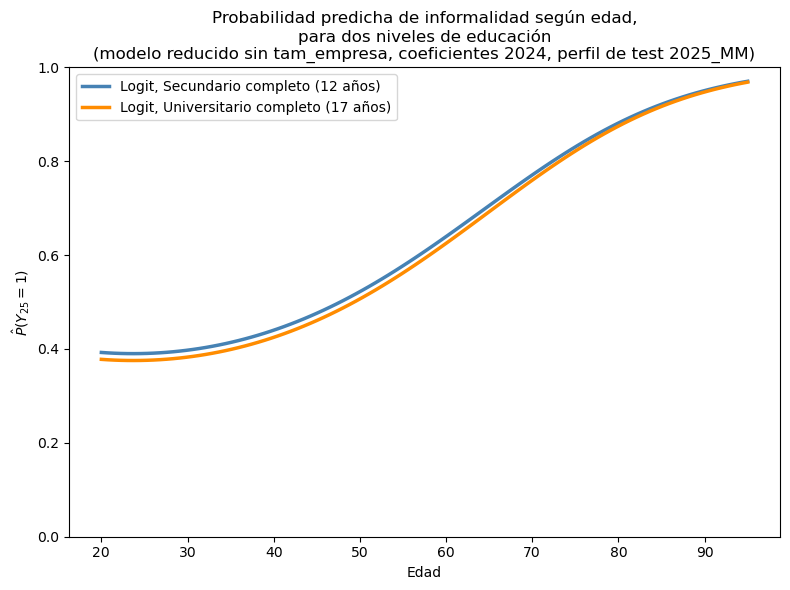

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Grilla de edad, acotada al rango observado en el set de testeo

edad_min, edad_max = X_2025_MM_final["edad"].min(), X_2025_MM_final["edad"].max()
edad_grid = np.linspace(edad_min, edad_max, 100)

niveles_educ = {12: "Secundario completo (12 años)", 17: "Universitario completo (17 años)"}
colores = {12: "steelblue", 17: "darkorange"}

# Perfil "representativo": resto de las variables en su media/moda
# calculadas sobre el TEST (ocupados_X_2025_MM), no sobre train.
# Sin tam_empresa, porque el modelo usado acá (modelo_2024_sin_tam) no la incluye.
perfil_base = {
    "horastrab": X_2025_MM_final["horastrab"].median(),
    "nhogar": X_2025_MM_final["nhogar"].mean(),
    "P21_miles": X_2025_MM_final["P21_miles"].quantile(0.10),
    "Género": X_2025_MM_final["Género"].mean(),
    "Cobertura": 0,   # sin cobertura de salud (perfil de riesgo)
}

fig, ax = plt.subplots(figsize=(8, 6))

for educ_val, etiqueta in niveles_educ.items():
    grilla = pd.DataFrame({"edad": edad_grid})
    grilla["edad2"] = grilla["edad"] ** 2
    grilla["educ"] = educ_val
    for var, val in perfil_base.items():
        grilla[var] = val
    grilla = sm.add_constant(grilla, has_constant="add")
    grilla = grilla[modelo_2024_sin_tam.params.index]  # mismo orden de columnas que el modelo reducido

    p_hat_grilla = modelo_2024_sin_tam.predict(grilla)
    ax.plot(edad_grid, p_hat_grilla, label=f"Logit, {etiqueta}",
             color=colores[educ_val], linewidth=2.5)

ax.set_xlabel("Edad")
ax.set_ylabel(r"$\hat{P}(Y_{25}=1)$")
ax.set_title("Probabilidad predicha de informalidad según edad,\npara dos niveles de educación\n"
             "(modelo reducido sin tam_empresa, coeficientes 2024, perfil de test 2025_MM)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("prob_informalidad_edad_educ.png", dpi=150)
plt.show()


La curva muestra una forma en S marcada, su probabilidad predicha de informalidad sube de forma pronunciada entre los 40 y los 75 años, pasando de ~0.40 a ~0.90. Es un efecto dominado por edad y edad2 en este modelo reducido (sin tam_empresa), más que por la educación.

La brecha entre educ=12 y educ=17 es visible pero chica (menos de 2 puntos porcentuales en cualquier punto de la curva), consistente con que la variable educ no haya resultado significativa incluso en esta especificación reducida
(p=0.242, sección anterior). El efecto de la educación sobre la informalidad, controlando por ingreso y cobertura de salud, es el esperado (mayor educación reduce el riesgo) pero de magnitud ligera y no distinguible del cero con confianza estadística convencional.

La pendiente marcada en edad, en cambio, sí es coherente con los coeficientes de edad y edad2 (significativos y con signos que generan una curva creciente y convexa en el tramo de edades altas):
para el perfil de riesgo simulado (sin cobertura de salud, ingreso bajo), la probabilidad de informalidad crece sustancialmente con la edad, más allá del nivel educativo alcanzado.

## C - Desempeño: matrices de confusión, ROC y métricas

In [42]:
import matplotlib.pyplot as plt

# Alineamos columnas de X_2025_MM con las que tiene el modelo 2024
# (X_2025_MM tiene informal_se_2024, que el modelo 2024 no conoce, decidimos deescartar)
X_2025_MM_para_modelo2024 = X_2025_MM_final.reindex(columns=modelo_2024.params.index, fill_value=0)

p_hat_2025 = modelo_2024.predict(X_2025_MM_para_modelo2024)

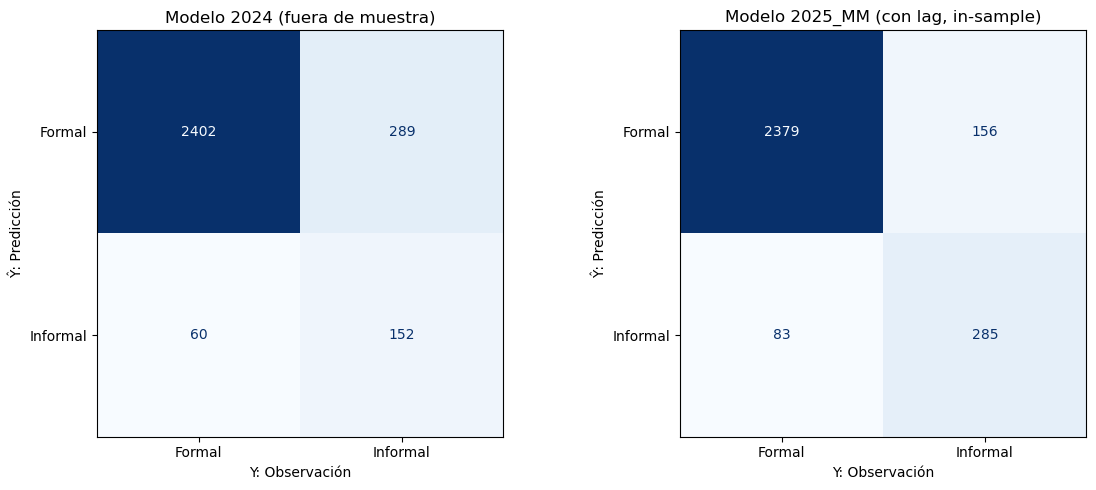

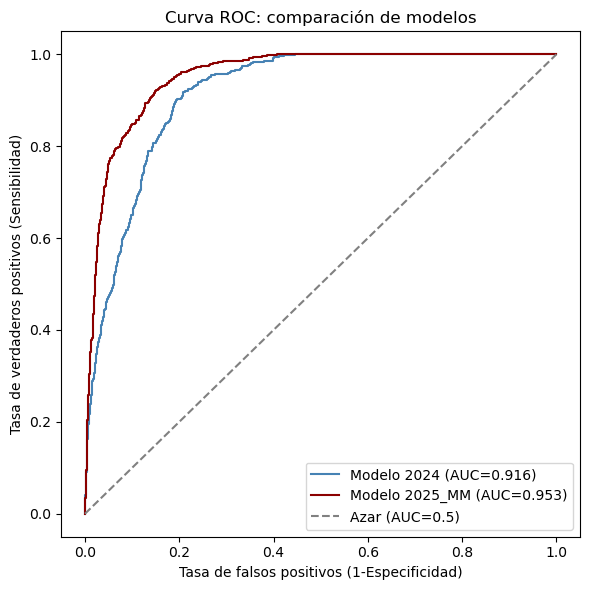

In [41]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay

# --- Modelo 1 (2024): predicción OUT-OF-SAMPLE sobre 2025_MM ---
y_hat_2024_en_2025 = (p_hat_2025 > 0.5).astype(int)
y_real_2025 = y_2025_MM.loc[X_2025_MM_final.index]

# --- Modelo 2 (2025_MM): ajustado y evaluado sobre la misma base (in-sample) ---
p_hat_2025MM = modelo_2025_MM.predict(X_2025_MM_final)
y_hat_2025MM = (p_hat_2025MM > 0.5).astype(int)

# Matrices de confusión

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_real_2025, y_hat_2024_en_2025)  # sklearn: filas=verdadero, col=predicho
disp1 = ConfusionMatrixDisplay(cm1.T, display_labels=["Formal", "Informal"])  # .T -> filas=predicho, col=verdadero
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Modelo 2024 (fuera de muestra)")
axes[0].set_xlabel("Y: Observación")
axes[0].set_ylabel("Ŷ: Predicción")

cm2 = confusion_matrix(y_real_2025, y_hat_2025MM)
disp2 = ConfusionMatrixDisplay(cm2.T, display_labels=["Formal", "Informal"])
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Modelo 2025_MM (con lag, in-sample)")
axes[1].set_xlabel("Y: Observación")
axes[1].set_ylabel("Ŷ: Predicción")

plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=150)
plt.show()

# Curva ROC (los dos modelos superpuestos)

fpr1, tpr1, _ = roc_curve(y_real_2025, p_hat_2025)
fpr2, tpr2, _ = roc_curve(y_real_2025, p_hat_2025MM)
auc1 = roc_auc_score(y_real_2025, p_hat_2025)
auc2 = roc_auc_score(y_real_2025, p_hat_2025MM)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr1, tpr1, label=f"Modelo 2024 (AUC={auc1:.3f})", color="steelblue")
ax.plot(fpr2, tpr2, label=f"Modelo 2025_MM (AUC={auc2:.3f})", color="darkred")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos (1-Especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (Sensibilidad)")
ax.set_title("Curva ROC: comparación de modelos")
ax.legend()
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=150)
plt.show()


De acuerdo con lo visto en clase, la diagonal principal son los aciertos (verdaderos negativos arriba-izquierda, verdaderos positivos abajo-derecha) y fuera de la diagonal están los errores tipo I (falsos positivos) y tipo II (falsos negativos).
Para la curva ROC, entendemos que cuanto más se acerque cada curva a la esquina superior izquierda, mejor clasifica el modelo (más sensibilidad con menos falsos positivos). La línea diagonal es el clasificador aleatorio (AUC=0,5). El AUC es "una suerte de R^2 para clasificación y sirve para comparar modelos, no para leerlo en términos absolutos como un porcentaje de acierto.

En nuestro caso, los dos modelos muestran una alta especificidad (98% y 97%) pareceeria que identifican muy bien a los trabajadores formales. Sin embargo, la diferencia relevante está en la sensibilidad porque el modelo 2024 detecta solo el 34% de los informales reales (152 de 441), dejando pasar 289 falsos negativos, mientras que el modelo 2025_MM casi duplica esa detección (65%, 285 de 441).

Esta caída de sensibilidad en el modelo 2024 respecto a especificaciones anteriores es esperable dado el resultado de la sección de coeficientes como tam_empresa_tam_no_micro que domina el modelo con un coeficiente muy negativo, el modelo tiende a clasificar como "Formal" a cualquiera que no esté en una microempresa, sin
matizar demasiado por el resto de las características y es una regla de decisión más rígida, que gana especificidad a costa de sensibilidad.

La curva ROC confirma que el modelo 2025_MM domina en todo el rango de umbrales (AUC=0.953 vs. 0.916), vemos que la brecha es más marcada en la zona de tasas de falsos positivos bajas (0-0.2), donde la curva del modelo 2025_MM se acerca más rápido a la esquina superior izquierda, es decir, para cualquier nivel de tolerancia a falsos positivos, el lag de informalidad permite detectar más informales reales que el modelo estructural solo.

In [40]:
# Especificidad no tiene función directa en sklearn -> la sacamos de la matriz de confusión
tn1, fp1, fn1, tp1 = cm1.ravel()  # cm1 = confusion_matrix del modelo 2024, ya la tenías
tn2, fp2, fn2, tp2 = cm2.ravel()  # cm2 = confusion_matrix del modelo 2025_MM

especificidad_2024 = tn1 / (tn1 + fp1)
especificidad_2025MM = tn2 / (tn2 + fp2)

metricas = pd.DataFrame({
    "Modelo": ["2024 (fuera de muestra)", "2025_MM (con lag)"],
    "Exactitud/Precisión (Accuracy)": [accuracy_score(y_real_2025, y_hat_2024_en_2025), accuracy_score(y_real_2025, y_hat_2025MM)],
    "Sensibilidad (Recall/TVP)": [recall_score(y_real_2025, y_hat_2024_en_2025), recall_score(y_real_2025, y_hat_2025MM)],
    "Valor predictivo positivo (Precision)": [precision_score(y_real_2025, y_hat_2024_en_2025), precision_score(y_real_2025, y_hat_2025MM)],
    "Especificidad": [especificidad_2024, especificidad_2025MM],
    "AUC-ROC": [auc1, auc2]
}).round(3)

display(metricas)

,Modelo,Exactitud/Precisión (Accuracy),Sensibilidad (Recall/TVP),Valor predictivo positivo (Precision),Especificidad,AUC-ROC
0,2024 (fuera de muestra),0.88,0.34,0.72,0.98,0.92
1,2025_MM (con lag),0.92,0.65,0.77,0.97,0.95


En las cinco métricas, el modelo 2025_MM domina al modelo 2024: tiene mejor precisión (92% vs. 88%), mejor sensibilidad (65% vs. 34% — la mejora más grande), mejor VPP (77% vs. 72%) y mejor AUC (0.95 vs. 0.92), con una especificidad apenas un punto menor (97% vs. 98%). No hay ningún trade-off ya que conocer el estatus de informalidad del año anterior mejora la clasificación en todos los frentes evaluados.

La brecha más marcada es en sensibilidad (+31 pp). Vemos que el modelo 2024 pierde a dos de cada tres informales reales (los clasifica como formales), mientras que el modelo 2025_MM reduce ese error a poco más de uno de cada tres.
Esto es consistente con el peso del predictor informal_se_2024 en la tabla de coeficientes (OR aprox. 13.5). Conocer el historial de informalidad de la persona aporta información que las características estructurales solas (edad, educación, tamaño de empresa, etc.) no logran capturar igual de bien.

Como ya aclaramos antes, el modelo 2025_MM está evaluado in-sample (ajustado y testeado sobre la misma base), mientras que el modelo 2024 es genuinamente fuera de muestra y parte de esta ventaja probablemente se achicaría si el modelo 2025_MM se evaluara también en un conjunto de test separado.

2. ¿qué modelo es "mejor" para la Secretaría de Trabajo?

El modelo 2025_MM va a tener AUC y precisión mucho más altas, casi enteramente por el peso de informal_se_2024 (OR≈8-9). Pero ahí nos encontramos con un problema conceptual para el caso de uso, ya que, si el modelo predice "informal en 2025" principalmente porque la persona ya era informal en 2024, el modelo no está agregando información nueva para la política pública, solo le está diciendo al Estado algo que un funcionario ya podría inferir mirando el registro del año anterior. Es útil para persistencia (confirmar quién sigue en la misma situación), pero tiene poco valor para identificar nuevos entrantes a la informalidad o anticipar el fenómeno en personas sin historial observado. El modelo 2024 (sin lag) identifica el perfil estructural asociado a informalidad (baja educación, trabajos temporales de pocas horas - como changas -, empresas chicas, sin cobertura de salud) es el que sirve para targetear con base en características observables sin necesitar el historial de la persona, lo cual es más realista si la Secretaría no tiene un panel individual actualizado de todos los trabajadores del país (teniendo en cuenta que la EPH es una muestra, no un censo). Para asignación de recursos escasos, importa más la precisión que el recall, cada persona mal clasificada como informal (falso positivo) es un recurso del programa mal asignado. En ese caso, conviene mirar la columna Precision de la tabla, no solo el AUC y probablemente, mover el umbral de 0.5 hacia arriba si el objetivo es maximizar la eficiencia del gasto en vez de la cobertura.

##  Herramientas de IA y reflexión final.

Para este trabajo el uso de la IA fue fundamental para guiar el proceso de selección de variables ya que al principio nos encontramos como muchas trabas respecto a la variable tam_empresa que nos opacaba todo el análisis y además el logit no tiene manera de identificar por separado el efecto de cada dummy de tamaño. En este sentido, le compartimos el código para que detecte el problema principal. En este trabajo en particular, no fue muy util como guia para las interpretaciones de los gráficos y tablas ya que los cambios realizados en el medio eran dificiles de seguir.

Claude:

#1 a partir de esta base, tengo que predecir si una persona es informal o no (cuentapropista informal) a partir de la base ocupados. En la tabla de diferencias de medias quiero separar significativo estadísticamente de relevante económicamente sin sobre interpretar.

#2 en el modelo 2 mi base de ocupados_X_2025_MM pierde el índice original y me tira error (adjunte foto) cuando agrego y_2025. Cómo lo ajusto?

#3 La tabla me tira errores estandar muy altos. Serviria eliminar la variable P21?

#4 El gráfico queda aplastado incluso modificando P21 a miles (foto)

#5 El modelo no converge y tengo el siguiente error: Warning: Maximum number of iterations has been exceeded.
...
converged: False
...
Possibly complete quasi-separation: A fraction 0.19 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified. -- Que está tomando mal?

#6 Si Practicamente el 100% de los cuentapropistas informales de la muestra son de empresas micro, cómo podria modificarlo para agregar la dummy que divida entre trabaja en empresa micro vs no trabaja?

#7 como y donde transpongo la matriz de confusion? 

#8 Para el gráfico de edad/educación quiero sacar la variable de tamaño de empresa para que se vea el efecto mas limpio, es posible? (foto del gráfico)

El tiempo total que nos llevó este trabajo fue de aproximadamente 8 horas.